In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("Fish.csv")
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [2]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


### simple linear regresstion

In [3]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

<Axes: >

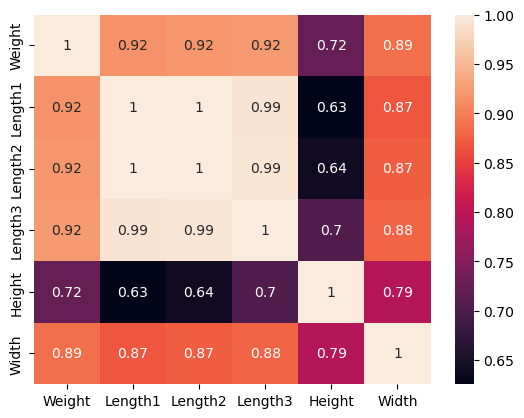

In [5]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Length1', ylabel='Weight'>

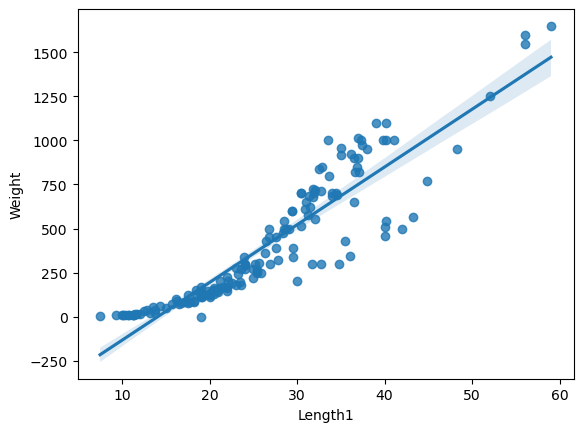

In [6]:
sns.regplot(data=df,x="Length1",y="Weight")

## For prediciting weight from length1

In [7]:
x=df[['Length1']]
y=df[['Weight']]

In [8]:
x,y

(     Length1
 0       23.2
 1       24.0
 2       23.9
 3       26.3
 4       26.5
 ..       ...
 154     11.5
 155     11.7
 156     12.1
 157     13.2
 158     13.8
 
 [159 rows x 1 columns],
      Weight
 0     242.0
 1     290.0
 2     340.0
 3     363.0
 4     430.0
 ..      ...
 154    12.2
 155    13.4
 156    12.2
 157    19.7
 158    19.9
 
 [159 rows x 1 columns])

## split in two part train and test

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(127, 1)
(32, 1)
(127, 1)
(32, 1)


## Bulid a model

In [12]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)

[[  80.9097957 ]
 [ -84.54996321]
 [ 509.15858348]
 [ 301.52280759]
 [ 217.17077363]
 [ 622.70939842]
 [-136.45890718]
 [ 301.52280759]
 [ 269.07971761]
 [1222.9065631 ]
 [ 541.60167346]
 [ 745.99314035]
 [ 489.69272949]
 [ 132.81873968]
 [ 570.80045445]
 [ 671.37403339]
 [ 840.0781013 ]
 [ 346.94313356]
 [ 249.61386362]
 [ 522.13581947]
 [ -97.5271992 ]
 [ 538.35736446]
 [ 479.95980249]
 [ 460.4939485 ]
 [ 671.37403339]
 [ 836.83379231]
 [ 233.39231862]
 [ 317.74435258]
 [-162.41337917]
 [ -97.5271992 ]
 [ 833.58948331]
 [  45.22239672]]


In [13]:
print(model.coef_) # y=mx+c , it is m

[[32.44308998]]


In [14]:
model.intercept_ # y=mx+c , it is c

array([-464.13411601])

In [15]:
y_pred=model.predict(x_test)

In [16]:
x_train

,Length1
75,15.0
138,43.2
2,23.9
86,20.0
45,20.5
...,...
71,24.0
106,25.9
14,29.4
92,20.5


In [17]:
print(x_test)
print(y_pred)

     Length1
78      16.8
155     11.7
128     30.0
55      23.6
94      21.0
29      33.5
147     10.1
51      23.6
98      22.6
141     52.0
19      31.0
60      37.3
15      29.4
65      18.4
24      31.9
30      35.0
126     40.2
101     25.0
96      22.0
16      30.4
151     11.3
18      30.9
12      29.1
9       28.5
31      35.0
125     40.1
95      21.5
56      24.1
145      9.3
152     11.3
135     40.0
76      15.7
[[  80.9097957 ]
 [ -84.54996321]
 [ 509.15858348]
 [ 301.52280759]
 [ 217.17077363]
 [ 622.70939842]
 [-136.45890718]
 [ 301.52280759]
 [ 269.07971761]
 [1222.9065631 ]
 [ 541.60167346]
 [ 745.99314035]
 [ 489.69272949]
 [ 132.81873968]
 [ 570.80045445]
 [ 671.37403339]
 [ 840.0781013 ]
 [ 346.94313356]
 [ 249.61386362]
 [ 522.13581947]
 [ -97.5271992 ]
 [ 538.35736446]
 [ 479.95980249]
 [ 460.4939485 ]
 [ 671.37403339]
 [ 836.83379231]
 [ 233.39231862]
 [ 317.74435258]
 [-162.41337917]
 [ -97.5271992 ]
 [ 833.58948331]
 [  45.22239672]]


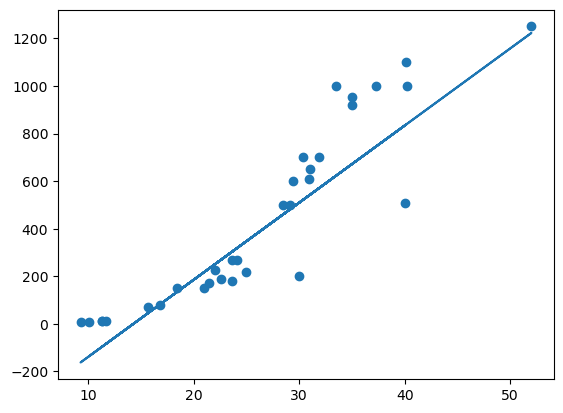

In [18]:
plt.plot(x_test,y_pred)
plt.scatter(x_test,y_test)
plt.show()

In [19]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [20]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

129.36788419512138
26796.684740821387
0.8116084146869396


In [21]:
model.predict(np.array([[25]]))

C:\Users\kaush\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[346.94313356]])

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import pandas as pd
import numpy as np

In [23]:
df=pd.read_csv('Fish.csv')
x=df.drop(['Species','Weight'],axis=1)
y=df[['Weight']]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

109.06327142039427
21303.013279012106
0.8679594534557271


## plot mse,r2_score for test size(0.75,0.8,0.85,0.9,0.95)

In [24]:
df=pd.read_csv('Fish.csv')
x=df.drop(['Species','Weight'],axis=1)
y=df[['Weight']]
test=[0.75,0.8,0.85,0.9,0.95]
mse=[]
r2=[]
for i in test:
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=i,random_state=40)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))

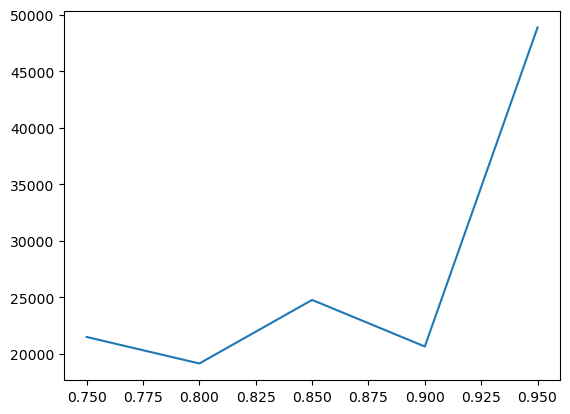

In [25]:
plt.plot(test,mse)

In [26]:
df=pd.read_csv('Ice_cream selling data.csv')
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [27]:
x=df[["Temperature (°C)"]]

y=df[['Ice Cream Sales (units)']]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

14.28681469049703
288.6596992061606
-0.4122082415321706


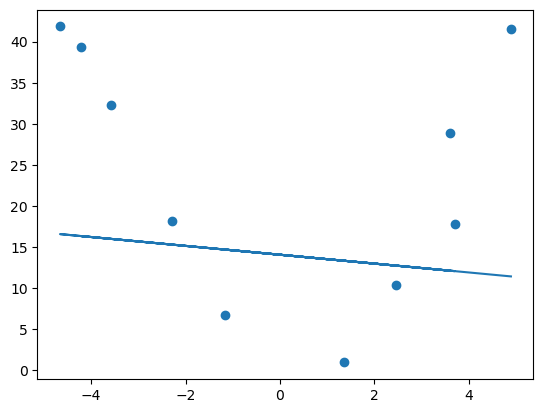

In [28]:
plt.plot(x_test,y_pred)
plt.scatter(x_test,y_test)
plt.show()

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

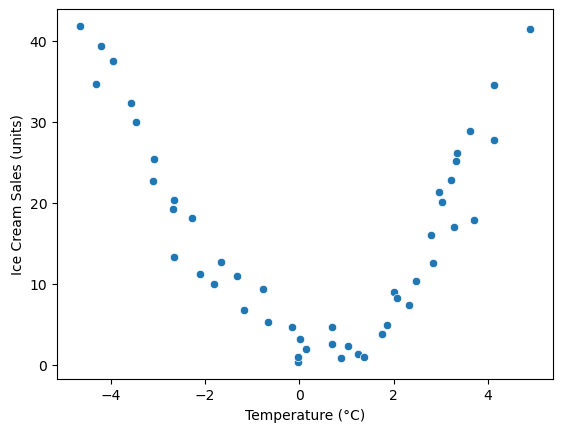

In [29]:
sns.scatterplot(data=df,x='Temperature (°C)',y='Ice Cream Sales (units)')

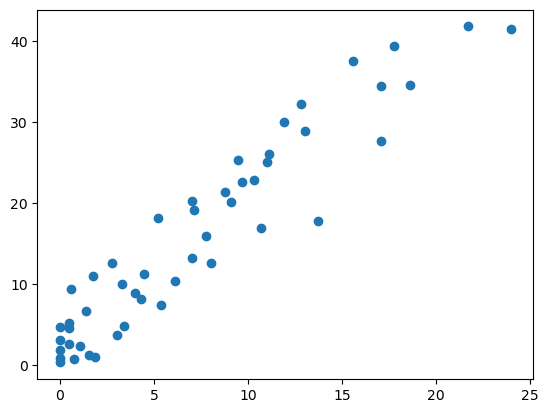

In [30]:
plt.scatter(df['Temperature (°C)']*df['Temperature (°C)'],df['Ice Cream Sales (units)'])